#### Biggest predictor of CO2 output

**What is the biggest predictor of a large CO2 output per capita of a country?**

To determine this you may want to consider things like GDP per capita, diets, number of cars per capita, various energy source, mobility and other factors.

Your answer can also be a specific combination of certain factors. Anyway, remember to include the explanations in your report.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

In [122]:
# Import the original Kaya Identity CO2 data
# df_original_data = pd.read_csv('https://raw.githubusercontent.com/majavanput/co2-emissions/main/data/kaya-identity-co2.csv')
df_original_data = pd.read_csv('../data/kaya-identity-co2.csv')

In [123]:
# Print information about the DataFrame
df_original_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17064 entries, 0 to 17063
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Entity                           17064 non-null  str    
 1   Code                             15810 non-null  str    
 2   Year                             17064 non-null  int64  
 3   CO₂ emissions                    14350 non-null  float64
 4   Energy intensity (Energy / GDP)  7882 non-null   float64
 5   GDP per capita                   9671 non-null   float64
 6   Population                       15412 non-null  float64
 7   Carbon intensity (CO₂ / energy)  10511 non-null  float64
 8   Carbon intensity (CO₂ / $)       10122 non-null  float64
 9   GDP per capita (Annotations)     13 non-null     str    
dtypes: float64(6), int64(1), str(3)
memory usage: 1.3 MB


In [124]:
# Overview of missing values per column
for name, values in df_original_data.items():
  print(f'Missing values in column {name}: ', df_original_data[name].isnull().sum())

# Total number of missing values in dataset
total_nan = df_original_data.isnull().sum().sum()
print(f"Total number of NaN values in the DataFrame: {total_nan}")

Missing values in column Entity:  0
Missing values in column Code:  1254
Missing values in column Year:  0
Missing values in column CO₂ emissions:  2714
Missing values in column Energy intensity (Energy / GDP):  9182
Missing values in column GDP per capita:  7393
Missing values in column Population:  1652
Missing values in column Carbon intensity (CO₂ / energy):  6553
Missing values in column Carbon intensity (CO₂ / $):  6942
Missing values in column GDP per capita (Annotations):  17051
Total number of NaN values in the DataFrame: 52741


In [125]:
df_co2_kaya = df_original_data.copy()

# Drop unnecessary columns
df_co2_kaya.drop(columns=['Code', 'Carbon intensity (CO₂ / $)', 'GDP per capita (Annotations)'], inplace=True)

# Rename columns
df_co2_kaya.rename(columns={'Energy intensity (Energy / GDP)': 'Energy intensity',
                             'Carbon intensity (CO₂ / energy)': 'Carbon intensity',
                             'CO₂ emissions': 'CO2 emissions'}, inplace=True)

In [126]:
df_co2_kaya.head()

,Entity,Year,CO2 emissions,Energy intensity,GDP per capita,Population,Carbon intensity
0,Afghanistan,1965,1006917.0,NaN,1290.0,10036003.0,NaN
1,Afghanistan,1966,1091159.0,NaN,1272.0,10266397.0,NaN
2,Afghanistan,1967,1281865.0,NaN,1277.0,10505961.0,NaN
3,Afghanistan,1968,1223391.0,NaN,1290.0,10756924.0,NaN
4,Afghanistan,1969,941232.0,NaN,1278.0,11017417.0,NaN


In [127]:
# Columns to analyze for correlation with CO2 emissions
correlation_columns = ['Energy intensity', 'GDP per capita', 'Population', 'Carbon intensity']

filtered_dfs = {}

for corr in correlation_columns:
    df_filtered = df_co2_kaya[['CO2 emissions', corr]].dropna()

    # Save the filtered dataframe
    filtered_dfs[corr] = df_filtered

    pearson_corr, p_value = pearsonr(df_filtered['CO2 emissions'], df_filtered[corr])
    spearman_corr = df_filtered.corr(method = 'spearman', numeric_only=True)

    print(f"{corr}")
    print(f"Pearson: {pearson_corr} (p = {p_value})")
    print(f"Spearman: {spearman_corr}")
    print("\n")

Energy intensity
Pearson: 0.02993682305286375 (p = 0.008289498195630218)
Spearman:                   CO2 emissions  Energy intensity
CO2 emissions          1.000000          0.491567
Energy intensity       0.491567          1.000000


GDP per capita
Pearson: 0.08633863279915378 (p = 1.1045257674075717e-16)
Spearman:                 CO2 emissions  GDP per capita
CO2 emissions        1.000000        0.649642
GDP per capita       0.649642        1.000000


Population
Pearson: 0.8947991302094506 (p = 0.0)
Spearman:                CO2 emissions  Population
CO2 emissions       1.000000    0.798097
Population          0.798097    1.000000


Carbon intensity
Pearson: -0.00018410603240244625 (p = 0.9849425070847573)
Spearman:                   CO2 emissions  Carbon intensity
CO2 emissions           1.00000           0.18281
Carbon intensity        0.18281           1.00000




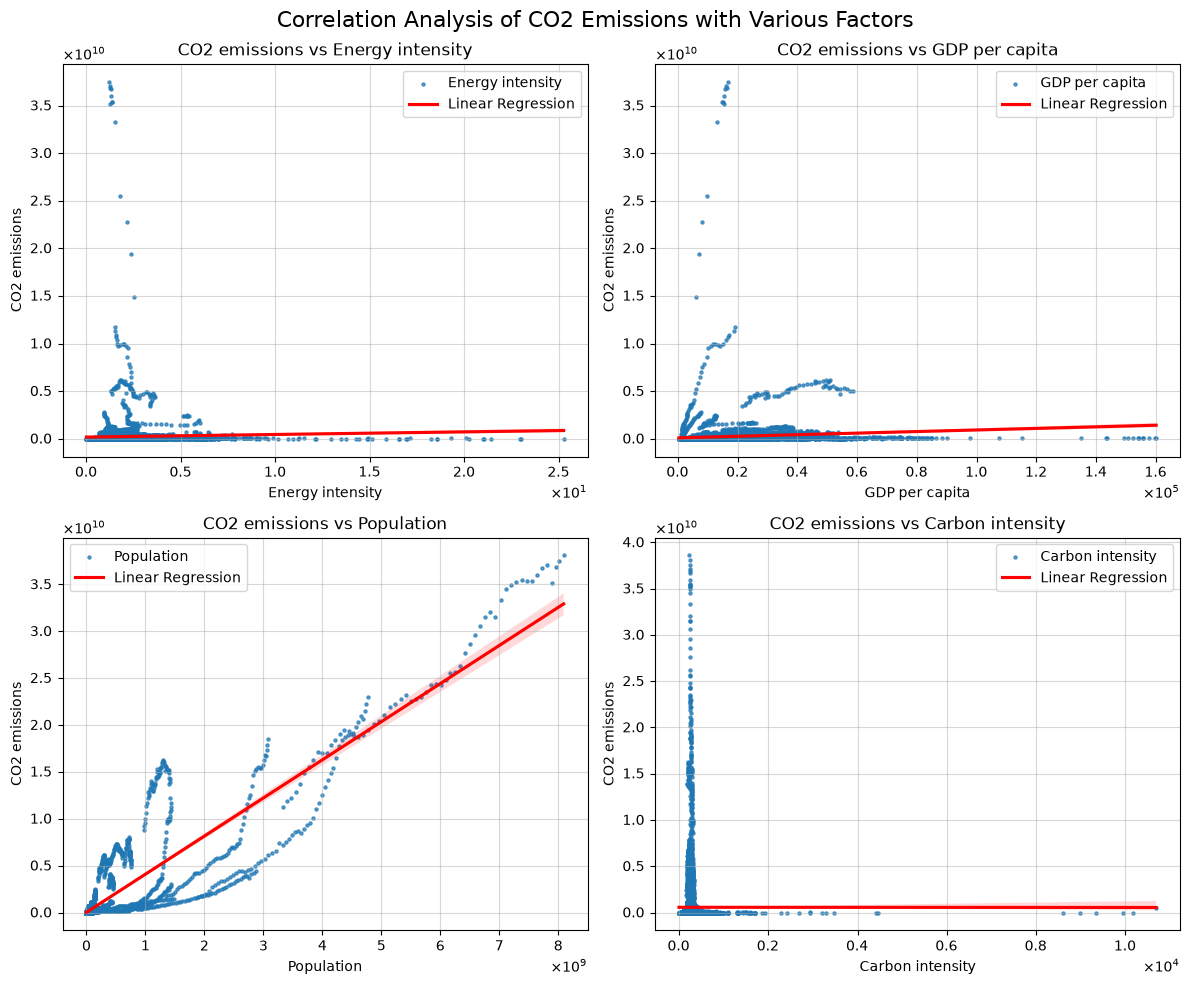

In [ ]:
# Select the relevant columns for correlation analysis
correlation_columns = ['Energy intensity', 'GDP per capita', 'Population', 'Carbon intensity']

# Create a figure and axis object for plotting the correlations
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# To access in for loop, flatten the axes array
axes = axes.flatten()

for i, corr in enumerate(correlation_columns):
    # Add a regression line with scatter points
    sns.regplot(data=filtered_dfs[corr], x=corr, y='CO2 emissions', ax=axes[i], scatter=True, label=corr,
        scatter_kws={'color': 'tab:blue', 'alpha': 0.7, 's': 5}, line_kws={'color': 'red', 'label': 'Linear Regression'})

    # Set title, labels, legend, grid
    axes[i].set_title(f'CO2 emissions vs {corr}')
    axes[i].set_xlabel(corr)
    axes[i].set_ylabel('CO2 emissions')
    axes[i].legend()
    axes[i].grid(alpha=0.5)

    # Use a mathematical expression for large numbers
    axes[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0), useMathText=True)

fig.suptitle('Correlation Analysis of CO2 Emissions with Various Factors', fontsize=16)
plt.tight_layout()
plt.show()

**What is the biggest predictor of a large CO2 output per capita of a country?**

Population is the biggest predictor of a large CO2 output per capita of a country, as it has the highest correlation coefficient with CO2 emissions.